In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
attractor_stim = pd.read_csv("../../data/eval/attractors/agreement_stimuli.csv")

In [4]:
attractor_stim.head()

,idx,distractors,condition,good,bad
0,0,0,subj_sg,The [wug] is happy.,The [wug] are happy.
1,1,0,subj_pl,The [wugs] are happy.,The [wugs] is happy.
2,2,1,subj_sg_d1_pl,The [wug] near the trees is happy.,The [wug] near the trees are happy.
3,3,1,subj_pl_d1_sg,The [wugs] near the tree are happy.,The [wugs] near the tree is happy.
4,4,2,subj_sg_d1_pl_d2_pl,The [wug] near the trees and behind the cars i...,The [wug] near the trees and behind the cars a...


In [5]:
import pandas as pd
attractor_stim = pd.read_csv("../../data/eval/attractors/agreement_stimuli.csv")

for cond, group in attractor_stim.groupby("condition", sort=False):
    print("=" * 60)
    print(f"CONDITION: {cond}")
    for _, row in group.head(2).iterrows():
        print(f"  good: {row['good']}")
        print(f"  bad:  {row['bad']}")

CONDITION: subj_sg
  good: The [wug] is happy.
  bad:  The [wug] are happy.
  good: The [wug] is happy.
  bad:  The [wug] are happy.
CONDITION: subj_pl
  good: The [wugs] are happy.
  bad:  The [wugs] is happy.
  good: The [wugs] are happy.
  bad:  The [wugs] is happy.
CONDITION: subj_sg_d1_pl
  good: The [wug] near the trees is happy.
  bad:  The [wug] near the trees are happy.
  good: The [wug] behind the cars is happy.
  bad:  The [wug] behind the cars are happy.
CONDITION: subj_pl_d1_sg
  good: The [wugs] near the tree are happy.
  bad:  The [wugs] near the tree is happy.
  good: The [wugs] behind the car are happy.
  bad:  The [wugs] behind the car is happy.
CONDITION: subj_sg_d1_pl_d2_pl
  good: The [wug] near the trees and behind the cars is happy.
  bad:  The [wug] near the trees and behind the cars are happy.
  good: The [wug] behind the cars and under the boxes is happy.
  bad:  The [wug] behind the cars and under the boxes are happy.
CONDITION: subj_pl_d1_sg_d2_sg
  good: Th

               model train_condition   number  distractors  mean_good  mean_bad    margin   n
Qwen3-VL-2B-Instruct          syntax   plural            0  -6.270380 -6.998641  0.728261 230
Qwen3-VL-2B-Instruct          syntax   plural            1  -7.184918 -7.571467  0.386549 230
Qwen3-VL-2B-Instruct          syntax   plural            2  -7.293207 -7.703397  0.410190 230
Qwen3-VL-2B-Instruct          syntax   plural            3  -6.587228 -6.871875  0.284647 230
Qwen3-VL-2B-Instruct          syntax   plural            4  -6.326359 -6.543071  0.216712 230
Qwen3-VL-2B-Instruct          syntax singular            0  -6.370924 -6.907609  0.536685 230
Qwen3-VL-2B-Instruct          syntax singular            1  -7.375136 -7.621875  0.246739 230
Qwen3-VL-2B-Instruct          syntax singular            2  -7.862092 -7.932201  0.070109 230
Qwen3-VL-2B-Instruct          syntax singular            3  -7.061685 -7.085190  0.023505 230
Qwen3-VL-2B-Instruct          syntax singular            4  

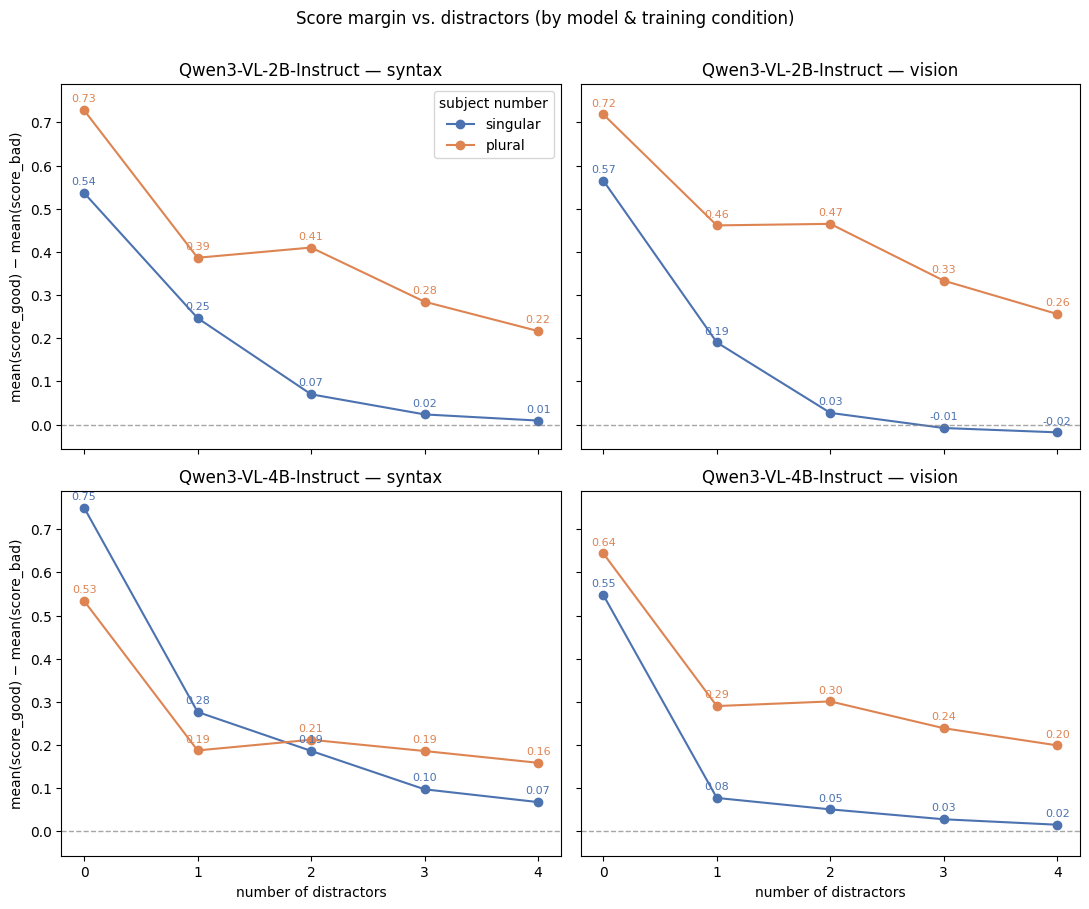

In [10]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_ROOT = "../../results/eval/attractors"
OUT_PNG = "../../results/eval/attractors/margin_by_distractors.png"

TRAIN_CONDITIONS = ["syntax", "vision"]
NUMBERS = ["singular", "plural"]
COLORS = {"singular": "#4C72B0", "plural": "#DD8452"}


def classify_number(good_sentence):
    """Singular if subject is [wug], plural if [wugs]. Check [wugs] first
    since '[wug]' is a substring of '[wugs]'."""
    s = str(good_sentence)
    if "[wugs]" in s:
        return "plural"
    if "[wug]" in s:
        return "singular"
    return "unknown"


# --- Collect all scored CSVs ---
paths = glob.glob(os.path.join(RESULTS_ROOT, "*", "*", "*scored*.csv"))
assert paths, f"No scored CSVs found under {RESULTS_ROOT}"

records = []
for p in sorted(paths):
    parts = p.split(os.sep)
    model = parts[-3]
    train_condition = parts[-2]

    df = pd.read_csv(p)
    df["score_good"] = df["score_good"].astype(float)
    df["score_bad"] = df["score_bad"].astype(float)
    df["number"] = df["good"].apply(classify_number)

    # mean(score_good) - mean(score_bad) by (number, distractors)
    for (number, distr), grp in df.groupby(["number", "distractors"]):
        mg = grp["score_good"].mean()
        mb = grp["score_bad"].mean()
        records.append({
            "model": model, "train_condition": train_condition,
            "number": number, "distractors": int(distr),
            "mean_good": mg, "mean_bad": mb, "margin": mg - mb, "n": len(grp),
        })

summary = pd.DataFrame(records)
print(summary.sort_values(["model", "train_condition", "number", "distractors"]).to_string(index=False))

# --- Plot grid: rows = models, cols = train_conditions; x = distractors, line per number ---
models = sorted(summary["model"].unique())
all_distractors = sorted(summary["distractors"].unique())

nrows, ncols = len(models), len(TRAIN_CONDITIONS)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows),
                         sharey=True, sharex=True, squeeze=False)

for r, model in enumerate(models):
    for c, tc in enumerate(TRAIN_CONDITIONS):
        ax = axes[r][c]
        sub = summary[(summary["model"] == model) & (summary["train_condition"] == tc)]
        for number in NUMBERS:
            s = sub[sub["number"] == number].sort_values("distractors")
            if len(s):
                ax.plot(s["distractors"], s["margin"], marker="o",
                        label=number, color=COLORS[number])
                for _, row in s.iterrows():
                    ax.annotate(f"{row['margin']:.2f}",
                                (row["distractors"], row["margin"]),
                                textcoords="offset points", xytext=(0, 6),
                                ha="center", fontsize=8, color=COLORS[number])
        ax.axhline(0.0, ls="--", color="gray", lw=1, alpha=0.7)
        ax.set_xticks(all_distractors)
        ax.set_title(f"{model} — {tc}")
        if r == nrows - 1:
            ax.set_xlabel("number of distractors")
        if c == 0:
            ax.set_ylabel("mean(score_good) − mean(score_bad)")

axes[0][0].legend(title="subject number")
fig.suptitle("Score margin vs. distractors (by model & training condition)", y=1.005)
fig.tight_layout()

os.makedirs(os.path.dirname(OUT_PNG), exist_ok=True)
fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
print(f"\nSaved plot to {OUT_PNG}")